In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import streamlit
import joblib

print("Everything Working ✅")

Everything Working ✅


In [2]:
df = pd.read_csv("bank-additional-full.csv",delimiter=";")
df.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In newer pandas version we need to mention dtype of the series of y bcuz only using replace will now convert its data type. so use astype

In [3]:
df['y'] = df['y'].replace({'yes': 1, 'no': 0}).astype(int)

In [4]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [5]:
#check no of missing values in each columns.
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
#IT RETURNS ALL THE UNIQUE VALUES FOR EACH COLUMN
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [7]:
#20 INPUTS 1 OUPUT
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [8]:
print(f"The shape of the dataset is {df.shape}. It contains {df.shape[0]} rows and {df.shape[1]} columns.")

The shape of the dataset is (41188, 21). It contains 41188 rows and 21 columns.


In [5]:
print(df['y'].unique())

[0 1]


In [10]:
#feature names and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


pandas.DataFrame.select_dtypes

DataFrame.select_dtypes(include=None, exclude=None)[source]

Return a subset of the DataFrame’s columns based on the column dtypes.

Notes

To select all numeric types, use np.number or 'number'

To select strings you must use the object dtype, but note that this will return all object dtype columns

The tolist() function is used to convert a given array to an ordinary list with the same items, elements, or values.

In [7]:
numerical_data = df.select_dtypes(include='number')
numerical_features = numerical_data.columns.to_list()
print(f"There are total {len(numerical_features)} numerical features.")
print(numerical_features)

There are total 11 numerical features.
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [8]:
categorical_data = df.select_dtypes(include=["object", "str"])
categorical_features = categorical_data.columns.to_list()
print(f"There are total {len(categorical_features)} categorical features.")
print(categorical_features)

There are total 10 categorical features.
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [14]:
numerical_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [15]:
categorical_data.describe(include='str')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563


To find the distributions and outlier in the each feature

Histogram

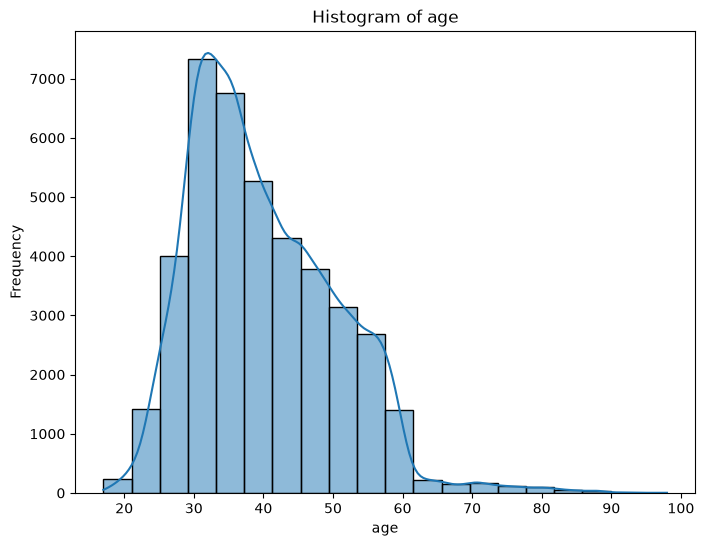

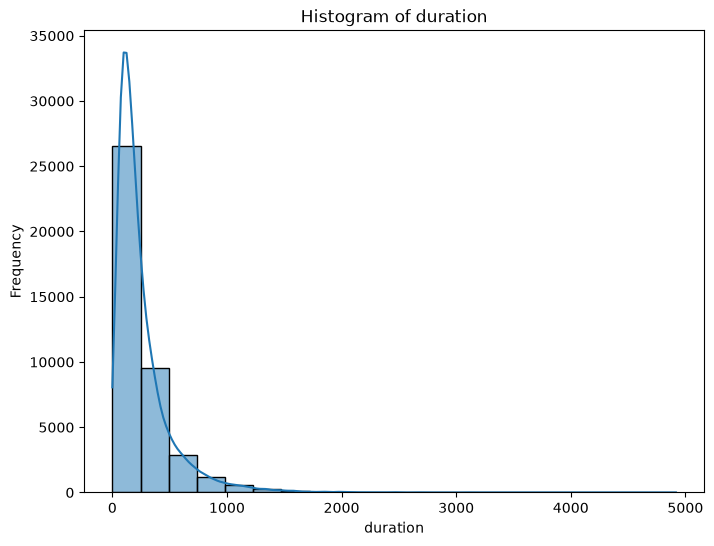

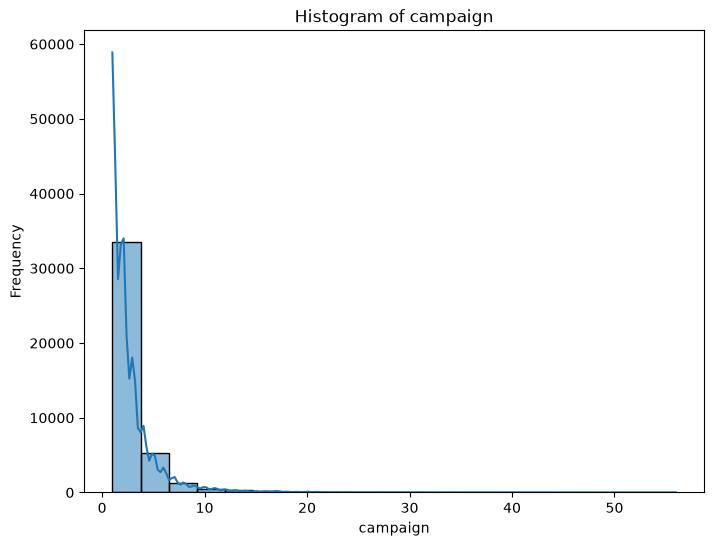

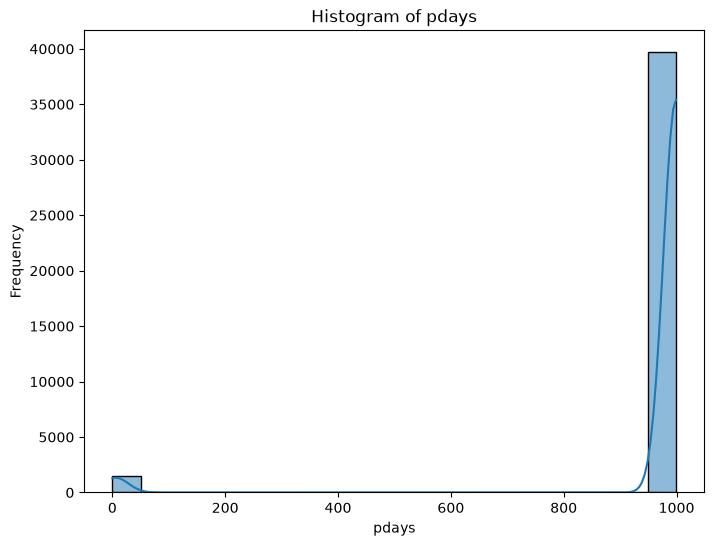

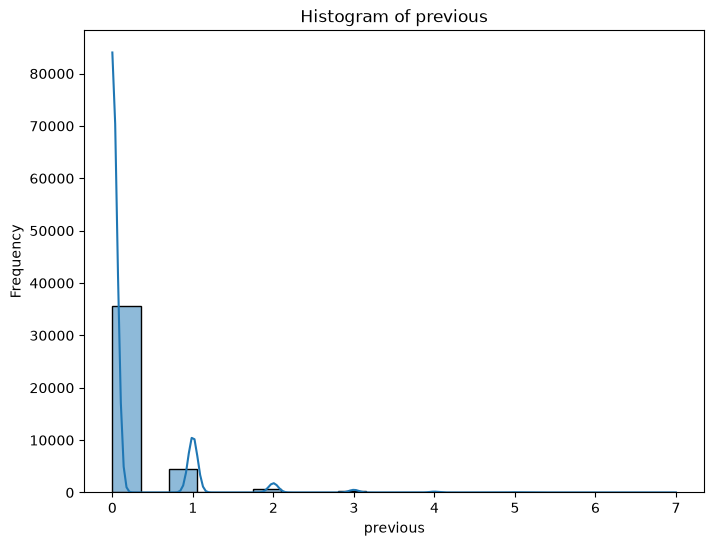

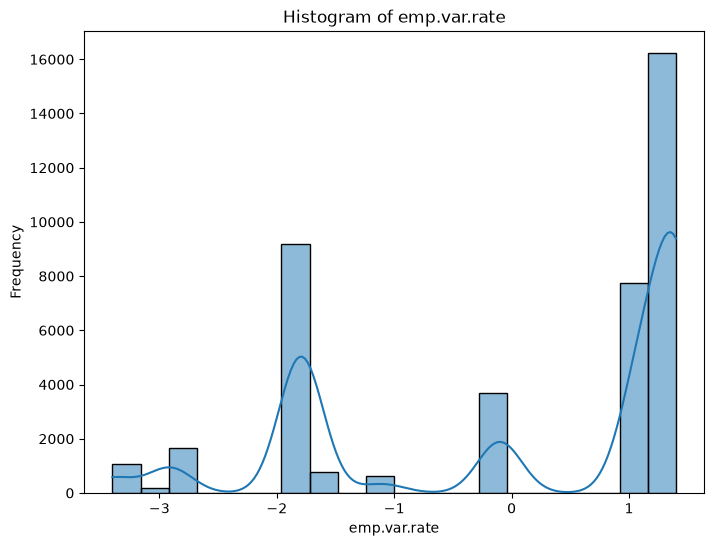

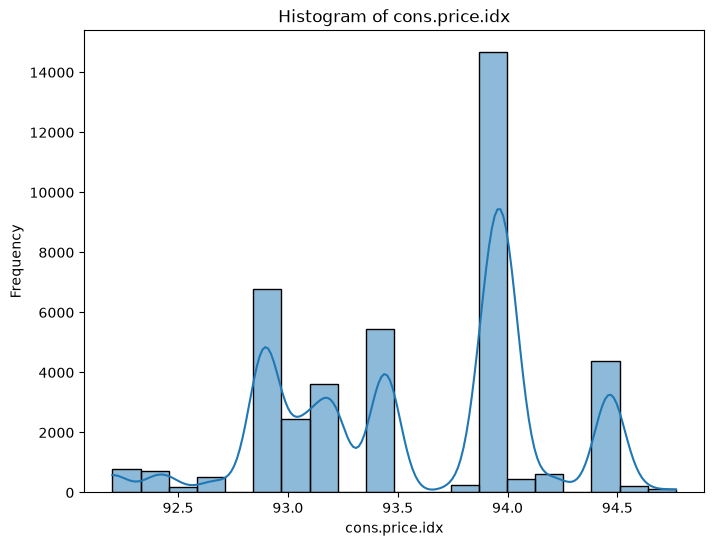

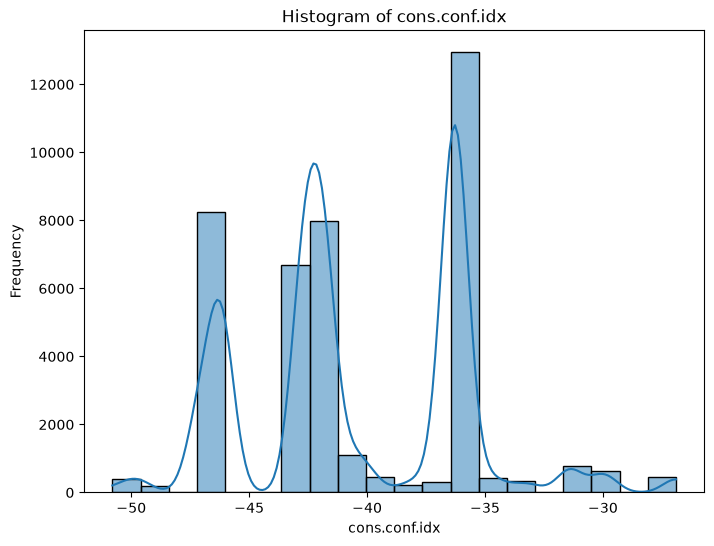

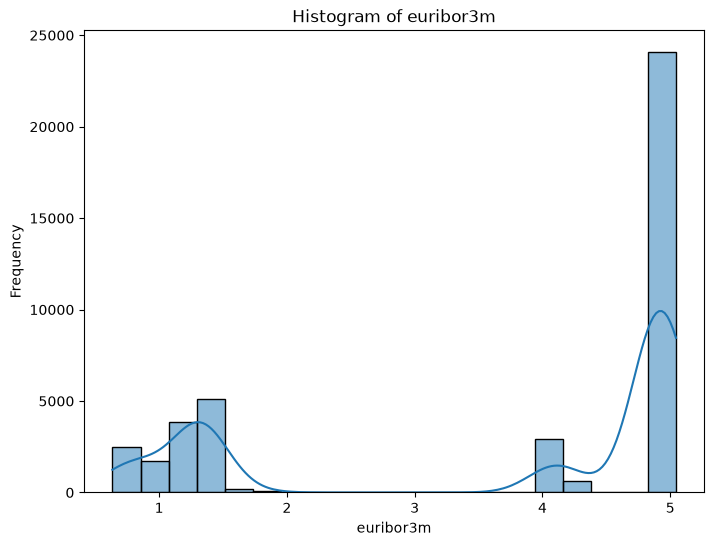

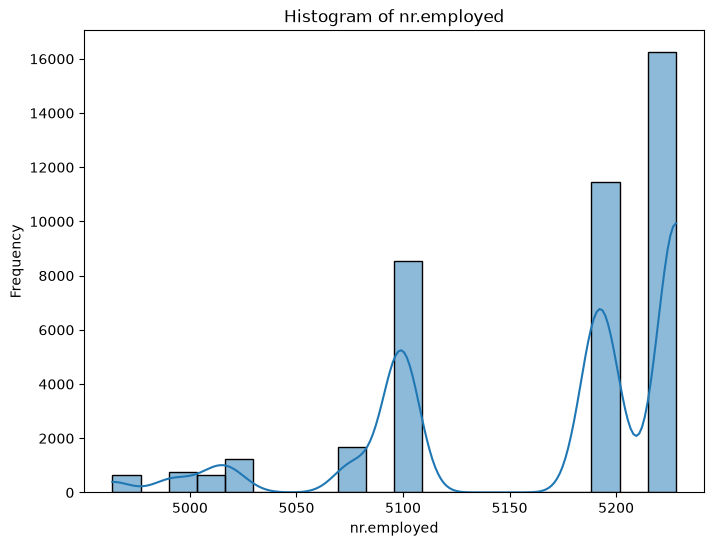

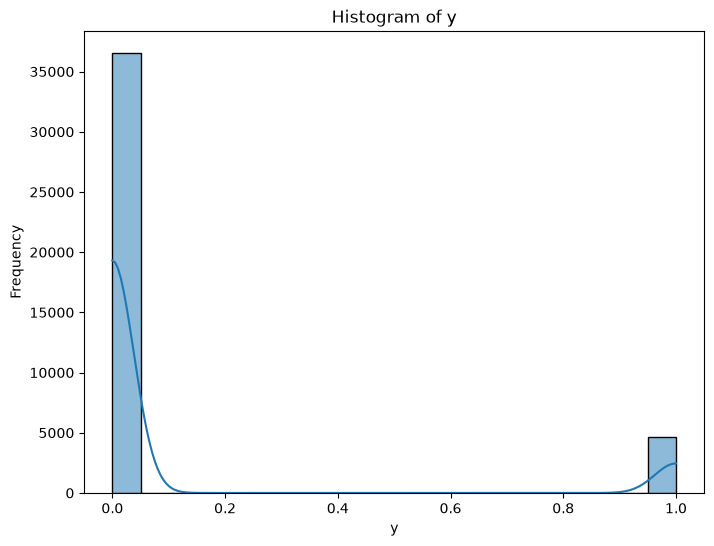

In [16]:
# numerical_data.hist(figsize=(12,12),bins=20)
# plt.show()

for feature in numerical_features:
    plt.figure(figsize=(8,6))
    sns.histplot(numerical_data[feature],bins=20,kde=True)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Frequency")
    plt.show()

In [18]:
numerical_data.nunique()

age                 78
duration          1544
campaign            42
pdays               27
previous             8
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [19]:
categorical_data.nunique()

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64

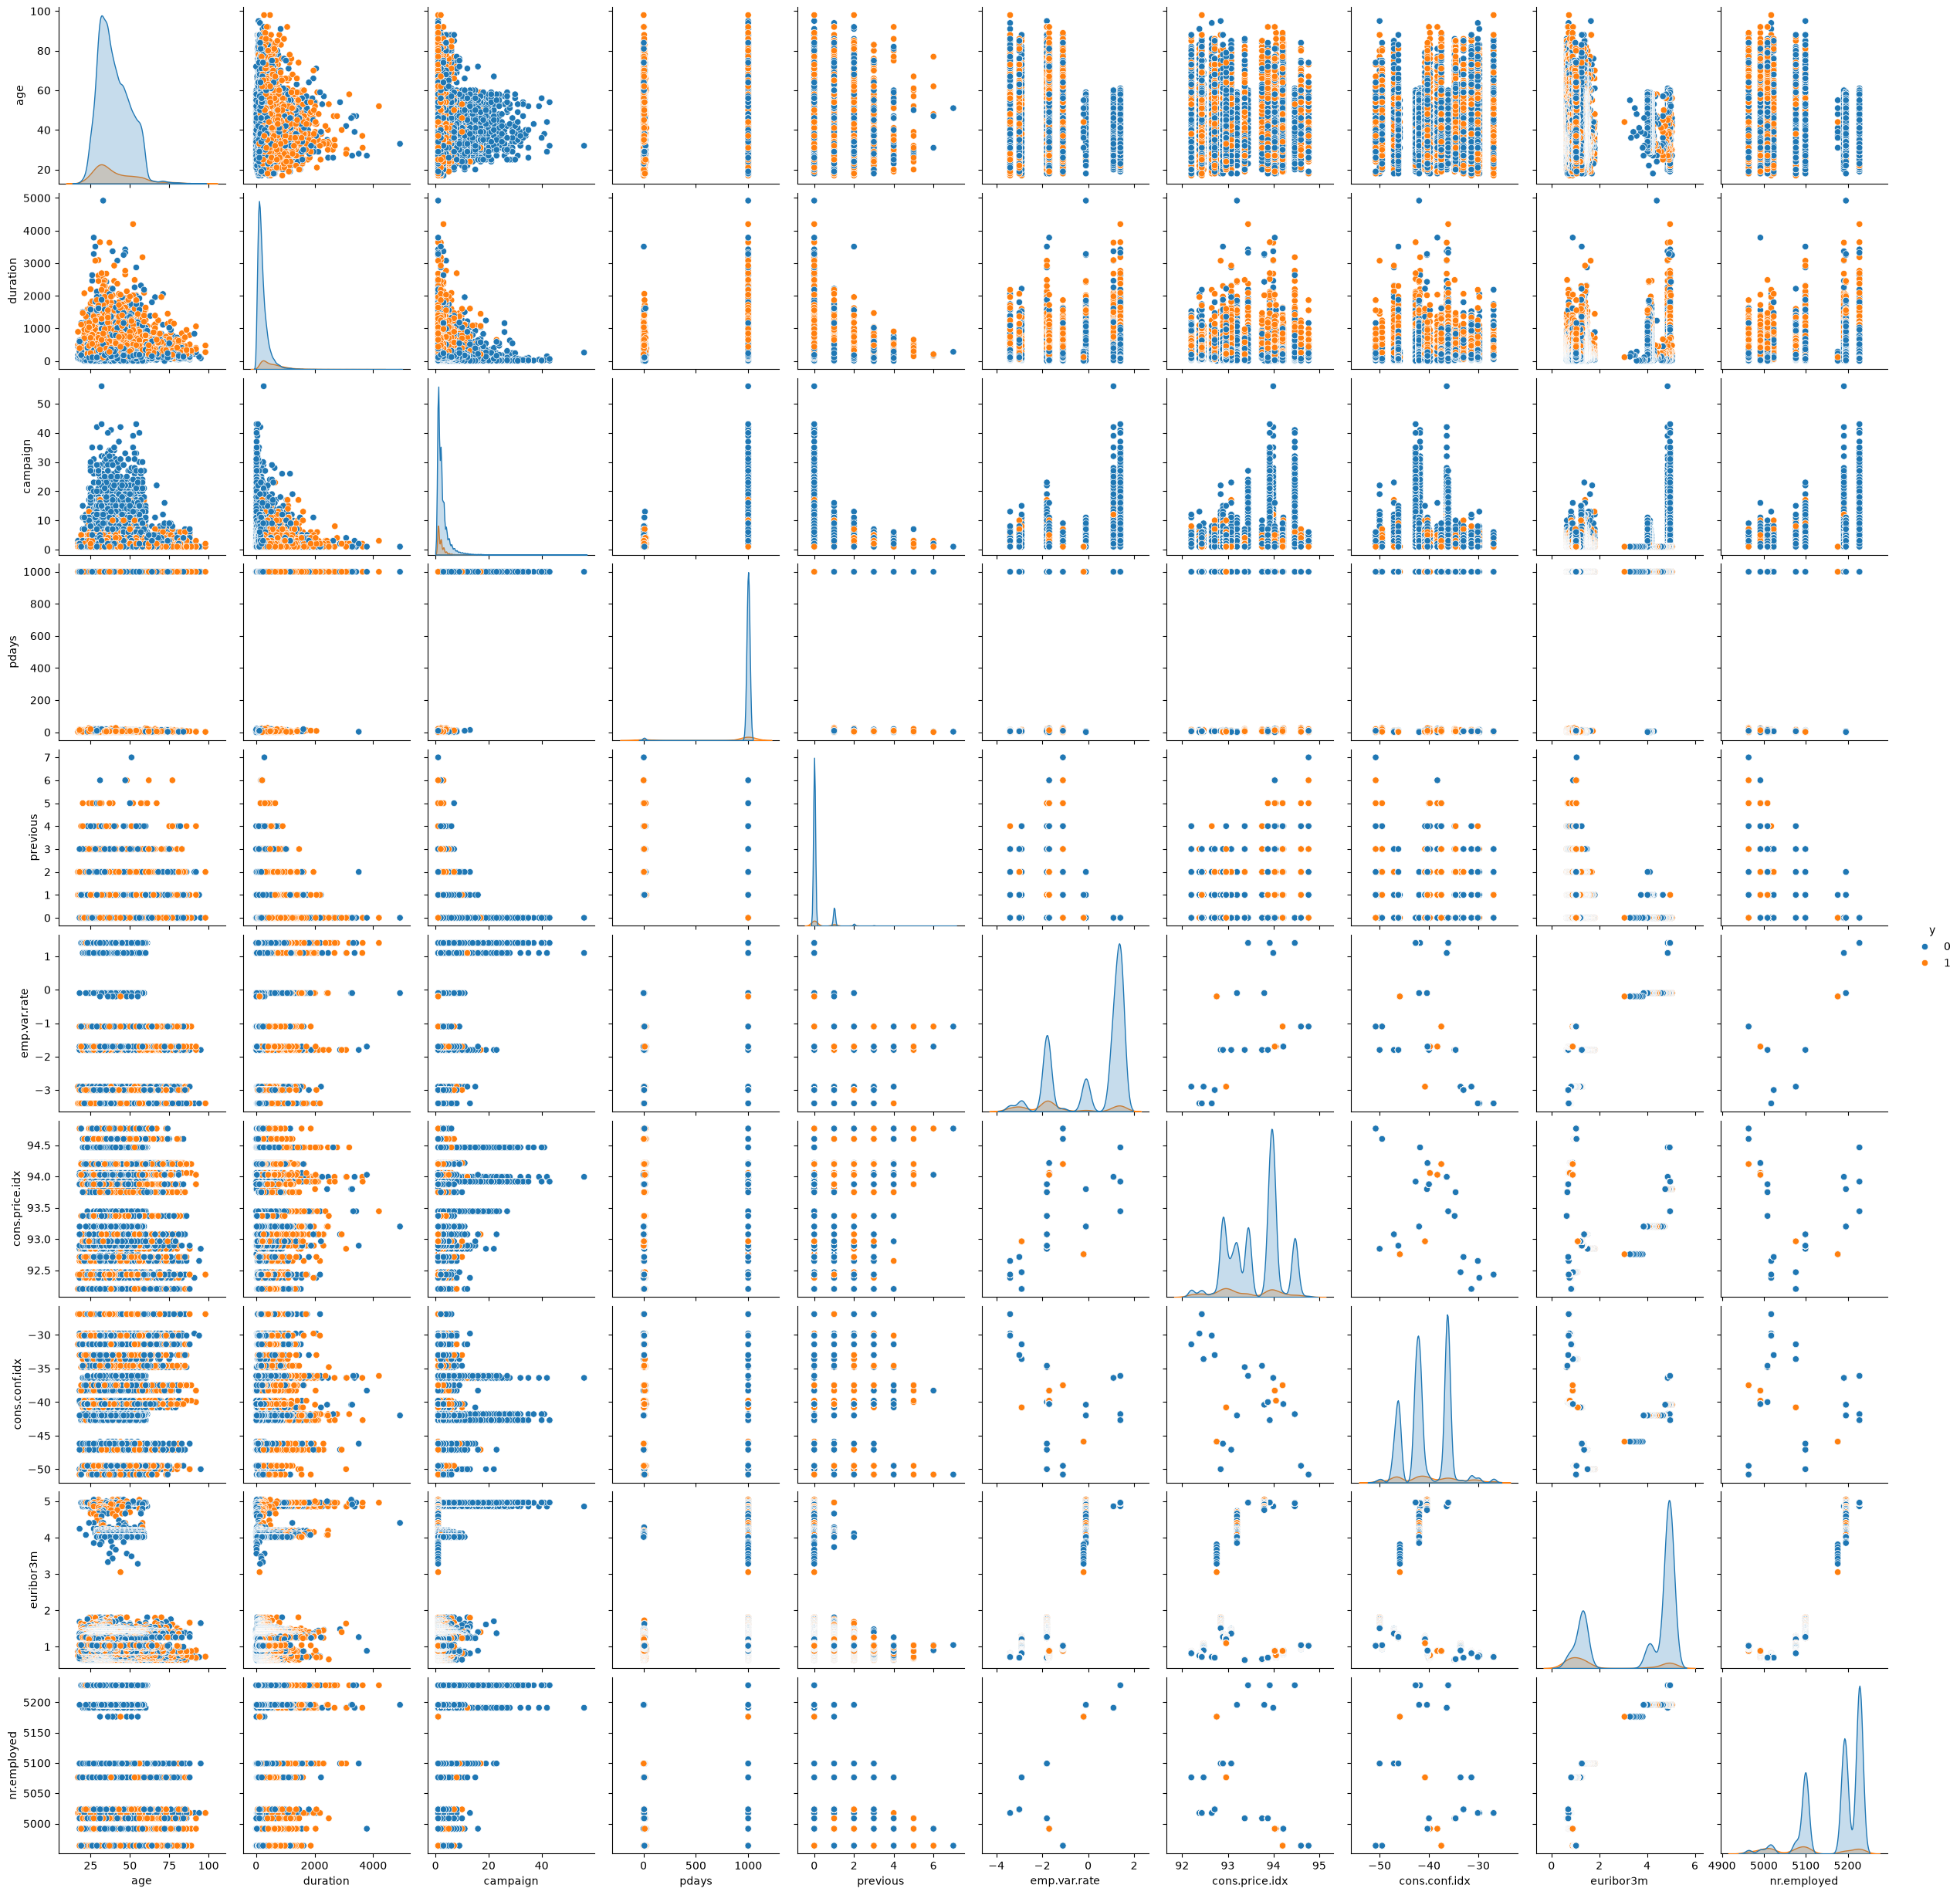

In [20]:
pairplots = sns.pairplot(numerical_data, hue='y')
# pairplots.fig.legend(labels = ['No Subsciption','Subscription'])
plt.show()

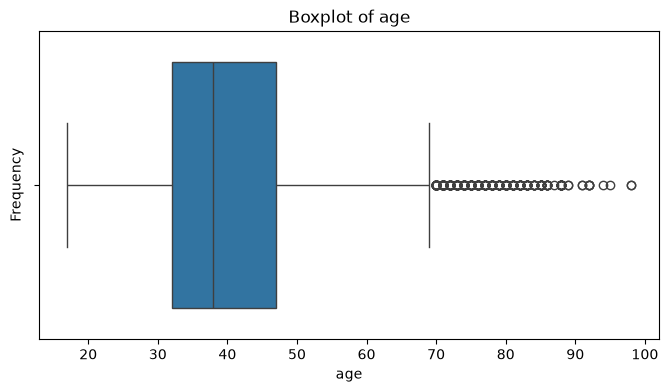

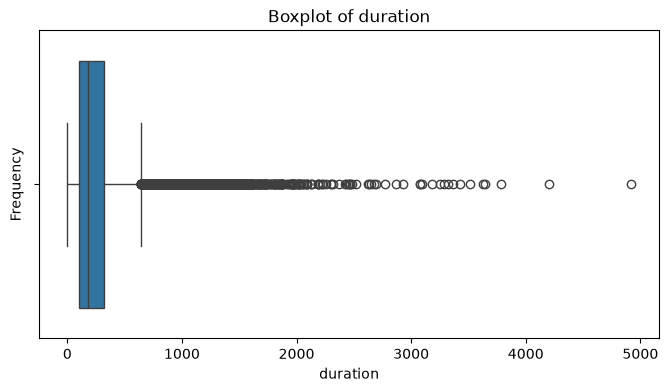

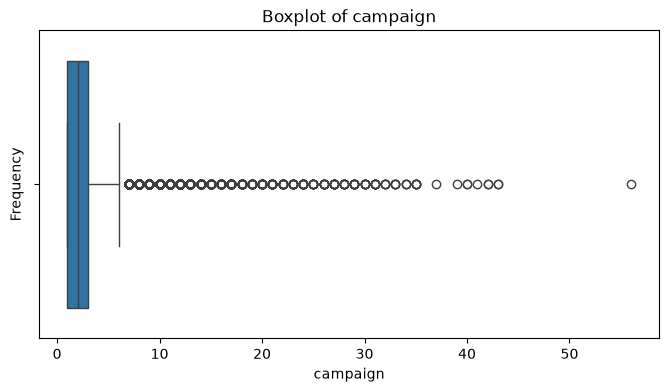

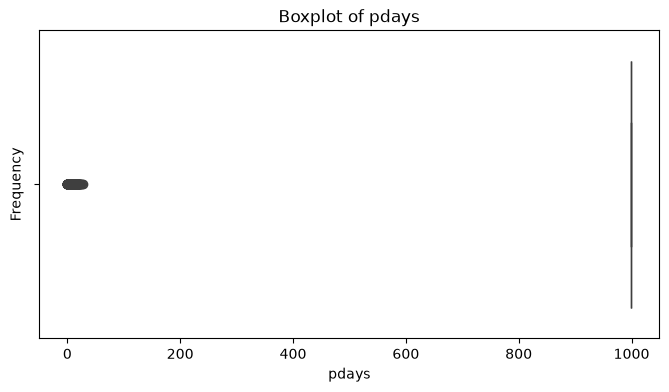

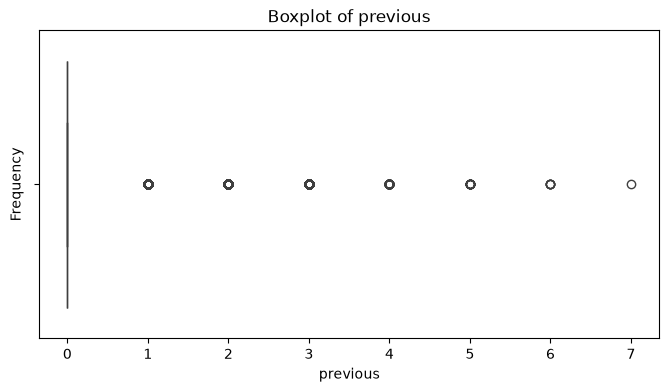

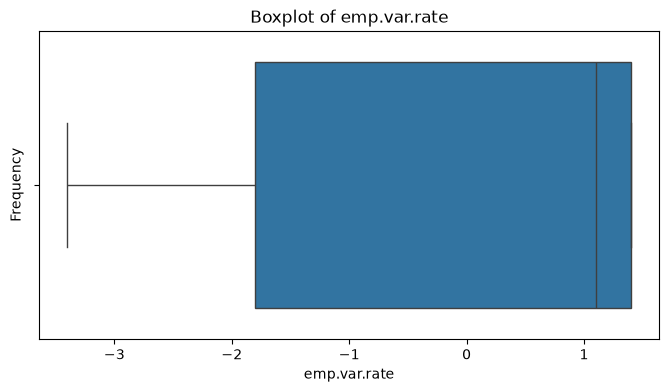

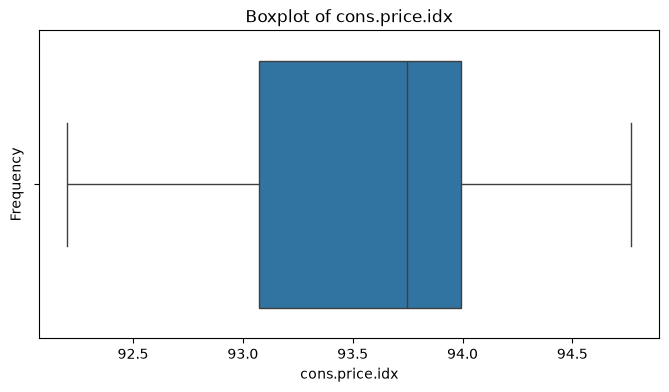

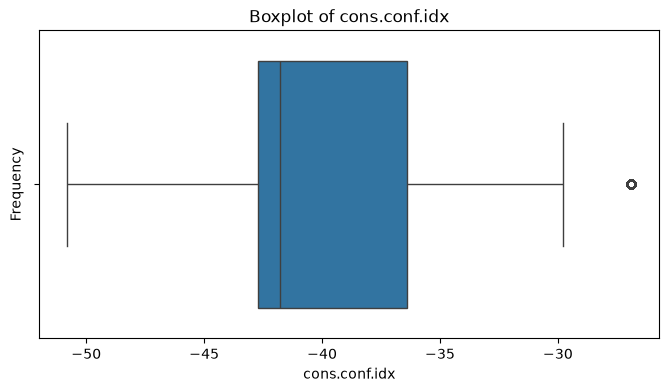

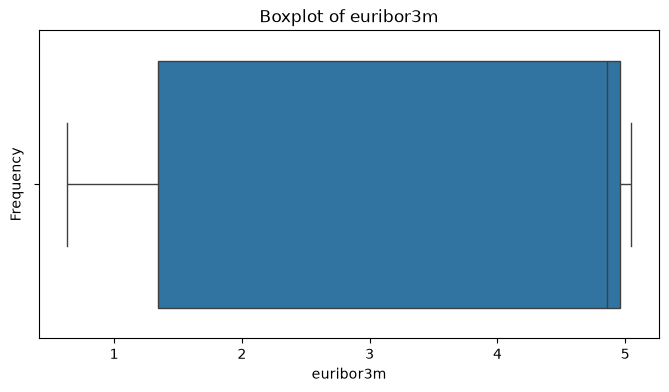

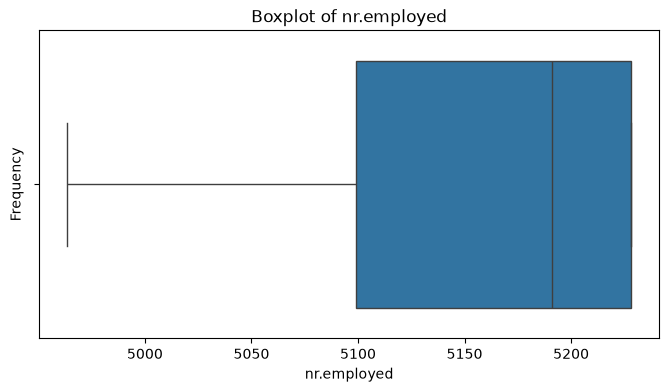

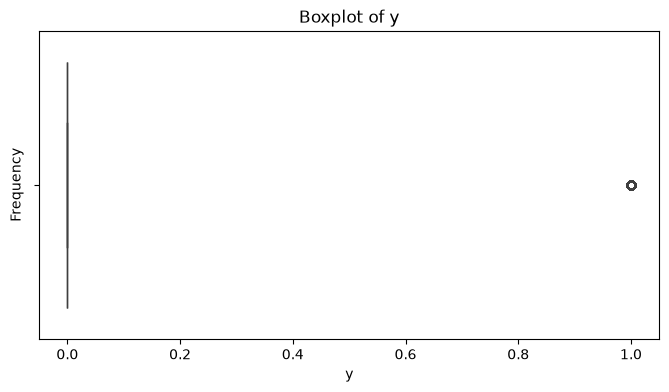

In [21]:
for feature in numerical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(data =numerical_data[feature], orient='h')
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Frequency")
    plt.show()

In [22]:
numerical_data.corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678


In [23]:
# numerical_data.corr().to_excel('output.xlsx')

better heatmap using seaborn

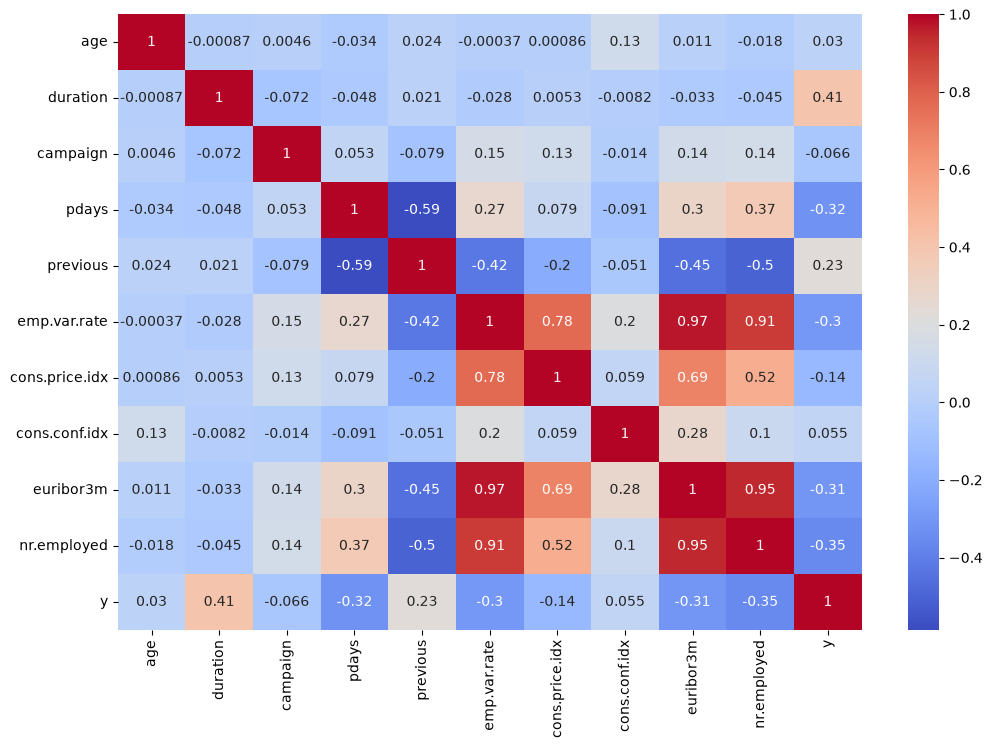

In [25]:
correlation = numerical_data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [9]:
class_counts = df.groupby('y').size()
print(class_counts)

total_instances = class_counts.sum()
print(total_instances)

percentages = (class_counts/total_instances)*100
print(percentages)

y
0    36548
1     4640
dtype: int64
41188
y
0    88.734583
1    11.265417
dtype: float64


In [10]:
class_df = pd.DataFrame({
    'Target': class_counts.index,
    'Count': class_counts.values,
    'Percentage': percentages.values
})

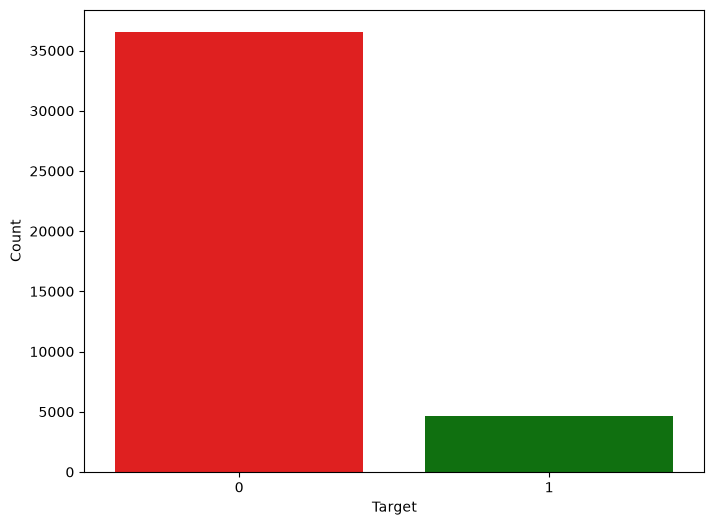

In [11]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=class_df,
    x='Target',
    y='Count',
    hue='Target',
    palette=['red', 'green'],
    legend=False
)

plt.show()

In [12]:
encoded_df = pd.get_dummies(df,columns=categorical_features, dtype=int)
encoded_df.head(10)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
5,45,198,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
6,59,139,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
7,41,217,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
8,24,380,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
9,25,50,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0


In [13]:
encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   duration                       41188 non-null  int64  
 2   campaign                       41188 non-null  int64  
 3   pdays                          41188 non-null  int64  
 4   previous                       41188 non-null  int64  
 5   emp.var.rate                   41188 non-null  float64
 6   cons.price.idx                 41188 non-null  float64
 7   cons.conf.idx                  41188 non-null  float64
 8   euribor3m                      41188 non-null  float64
 9   nr.employed                    41188 non-null  float64
 10  y                              41188 non-null  int64  
 11  job_admin.                     41188 non-null  int64  
 12  job_blue-collar                41188 non-null  int64  
 1

In [14]:
# class count
class_count_0, class_count_1 = encoded_df['y'].value_counts()
print(class_count_0)
print(class_count_1)
# Separate class
class_0 = encoded_df[encoded_df['y'] == 0]
class_1 = encoded_df[encoded_df['y'] == 1]# print the shape of the class
print('class 0:', class_0.shape)
print('class 1:', class_1.shape)

36548
4640
class 0: (36548, 64)
class 1: (4640, 64)


total class of 1 and0: 0    4640
1    4640
Name: y, dtype: int64


<AxesSubplot:title={'center':'count(target)'}>

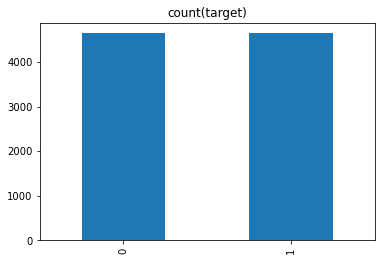

In [18]:
class_0_under = class_0.sample(class_count_1)
test_under = pd.concat([class_0_under,class_1],axis=0)
print("total class of 1 and0:",test_under['y'].value_counts())
# plot the count after under-sampeling
test_under['y'].value_counts().plot(kind='bar',title = "count(target)")

In [10]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
from imblearn.under_sampling import NearMiss

In [35]:
nm = NearMiss()

In [23]:
smote = SMOTE()

In [28]:
X_smote, y_smote = smote.fit_resample(X_train,y_train)
print('Original dataset shape', Counter(y_train))
print('Resample dataset shape', Counter(y_smote))

Original dataset shape Counter({0: 25570, 1: 3261})
Resample dataset shape Counter({0: 25570, 1: 25570})


In [36]:
X_nm, y_nm = nm.fit_resample(X_train,y_train)
print('Original dataset shape', Counter(y_train))
print('Resample dataset shape', Counter(y_nm))

Original dataset shape Counter({0: 25570, 1: 3261})
Resample dataset shape Counter({0: 3261, 1: 3261})


In [15]:
X = encoded_df.drop(['y', 'duration'], axis=1)
y = encoded_df['y']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101,stratify=y)

In [19]:
print(X_train)

       age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
26774   39         1    999         0          -0.1          93.200   
16399   23         1    999         0           1.4          93.918   
27845   34        13    999         0          -1.8          92.843   
16506   40         1    999         0           1.4          93.918   
25760   29         1    999         0          -0.1          93.200   
...    ...       ...    ...       ...           ...             ...   
25101   38         1    999         0          -0.1          93.200   
6697    59         2    999         0           1.1          93.994   
31539   32         1    999         0          -1.8          92.893   
10636   44         2    999         0           1.4          94.465   
15887   31         1    999         0           1.4          93.918   

       cons.conf.idx  euribor3m  nr.employed  job_admin.  ...  month_oct  \
26774          -42.0      4.076       5195.8           0  ...          

In [20]:
# 3. Combine X_train and y_train
train_df = X_train.copy()
train_df['y'] = y_train

In [21]:
# 4. Separate majority and minority classes
class_0 = train_df[train_df['y'] == 0]
class_1 = train_df[train_df['y'] == 1]

undersampling

In [18]:
# 5. Under Sample ONLY the majority class
class_0_under = class_0.sample(
    n=len(class_1),
    random_state=101
)

In [19]:
# 6. Combine both classes
train_under = pd.concat(
    [class_0_under, class_1],
    axis=0
).sample(frac=1, random_state=101)

In [20]:
# 7. Check balance
print(train_under['y'].value_counts())


y
0    3248
1    3248
Name: count, dtype: int64


In [21]:
# 8. Separate X_train and y_train again
X_train = train_under.drop('y', axis=1)
y_train = train_under['y']

In [22]:
# 9. Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Oversampling

In [22]:
class_1_over = class_1.sample(n=len(class_0),replace = True, random_state = 101)

#combine them
train_over = pd.concat([class_0, class_1_over], axis=0).sample(frac=1, random_state=101)

In [23]:
# 7. Check balance
print(train_over['y'].value_counts())

y
0    25583
1    25583
Name: count, dtype: int64


this is same for all sampling techniques but i wrote for all .

In [24]:
# 8. Separate X_train and y_train again
X_train = train_over.drop('y', axis=1)
y_train = train_over['y']

In [20]:
# 9. Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote technique

In [20]:
smote = SMOTE(random_state=101)

In [21]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [22]:
print(Counter(y_train))
print(Counter(y_train_smote))

Counter({0: 25583, 1: 3248})
Counter({1: 25583, 0: 25583})


scaling for smote

In [21]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [22]:
logistic_model = LogisticRegression(max_iter=1000)

In [23]:
logistic_model.fit(X_train_scaled,y_train_smote)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Logistic Regression

In [20]:
logistic_model = LogisticRegression(max_iter=1000)

In [21]:
logistic_model.fit(X_train,y_train)

c:\Users\abhik\Documents\ml project\Term-Deposit-Forecasting-in-Direct-Marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [24]:
predictions = logistic_model.predict(X_test_scaled)

In [25]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10965
           1       0.61      0.25      0.35      1392

    accuracy                           0.90     12357
   macro avg       0.76      0.61      0.65     12357
weighted avg       0.88      0.90      0.88     12357



In [26]:
confusion_matrix(y_test,predictions)
# pd.crosstab(y_test, predictions, rownames = ['Actual'], colnames =['Predicted'], margins = True)

array([[10741,   224],
       [ 1047,   345]])

In [27]:
accuracy = accuracy_score(y_test,predictions)
rounded_accuracy = round(accuracy, 2)*100
print("Accuracy:", rounded_accuracy)

Accuracy: 90.0


Testing xgboost now for all sampling techniques without randomizedsearchcv first

In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform



In [26]:
xgb_model = XGBClassifier(
    random_state=101,
    eval_metric = "logloss"
    
)

In [27]:
param_dist = {

    "n_estimators": randint(100, 500),

    "max_depth": randint(3, 10),

    "learning_rate": loguniform(0.01, 0.3),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "gamma": uniform(0, 5),

    "min_child_weight": randint(1, 10),

    "reg_alpha": loguniform(1e-4, 10),

    "reg_lambda": loguniform(1e-4, 10)
}

In [28]:
random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_dist,

    n_iter=30,

    scoring='f1',

    cv=5,

    verbose=2,

    random_state=101,

    n_jobs=-1

)

In [29]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....002718AEF3110>, 'gamma': <scipy.stats....002718FC53950>, 'learning_rate': <scipy.stats....002718FC36120>, 'max_depth': <scipy.stats....002718AEF2850>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",101
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a 

In [30]:
print(random_search.best_params_)

{'colsample_bytree': np.float64(0.9568255530423748), 'gamma': np.float64(0.3784094882060568), 'learning_rate': np.float64(0.1658017142586433), 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 471, 'reg_alpha': np.float64(0.0014513371399649806), 'reg_lambda': np.float64(0.0002617020763266475), 'subsample': np.float64(0.8414193689164874)}


In [31]:
print(random_search.best_score_)

0.8769692899098175


In [32]:
best_xgb = random_search.best_estimator_

In [33]:
predictions = best_xgb.predict(X_test)

In [34]:
print(classification_report(y_test, predictions))

print(confusion_matrix(y_test, predictions))


              precision    recall  f1-score   support

           0       0.94      0.88      0.91     10965
           1       0.37      0.54      0.44      1392

    accuracy                           0.84     12357
   macro avg       0.65      0.71      0.67     12357
weighted avg       0.87      0.84      0.86     12357

[[9688 1277]
 [ 642  750]]


In [35]:
accuracy = accuracy_score(y_test,predictions)
rounded_accuracy = round(accuracy, 2)*100
print("Accuracy:", rounded_accuracy)

Accuracy: 84.0


<Figure size 1000x800 with 0 Axes>

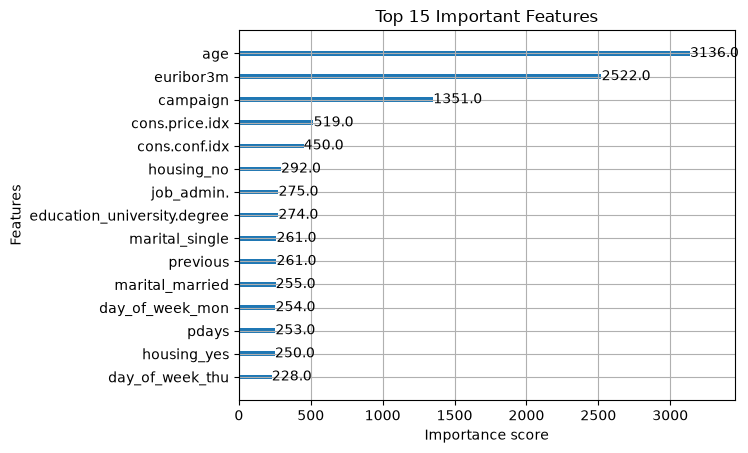

In [36]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    best_xgb,
    max_num_features=15
)

plt.title("Top 15 Important Features")
plt.show()

Feature gain graph
weight (default)	Number of times a feature was used in tree splits
gain ⭐	Average improvement in model performance when using that feature
cover	Number of samples affected by the feature's splits

<Figure size 1000x800 with 0 Axes>

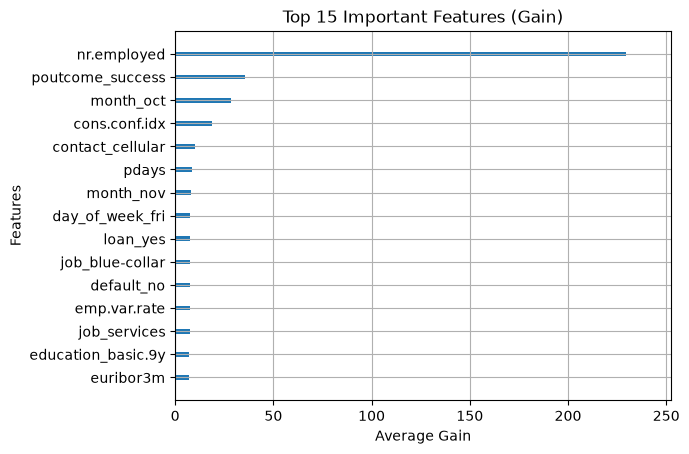

In [37]:
plt.figure(figsize=(10, 8))

ax = plot_importance(
    best_xgb,
    importance_type="gain",
    max_num_features=15,
    show_values=False   # Hide long numbers
)

plt.title("Top 15 Important Features (Gain)")
plt.xlabel("Average Gain")
plt.ylabel("Features")
plt.show()

ROC AUC CURVE

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

In [39]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

In [40]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [41]:
auc = roc_auc_score(y_test,y_prob)

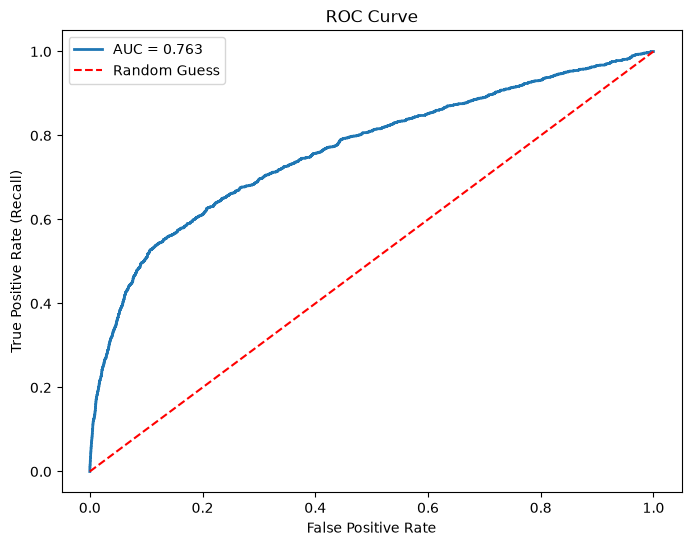

In [42]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='red',
    label='Random Guess'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")

plt.legend()

plt.show()

precision - recall curve

In [43]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [44]:
precision,recall,thresholds = precision_recall_curve(
    y_test,
    y_prob
)

In [45]:
ap = average_precision_score(
    y_test,
    y_prob
)

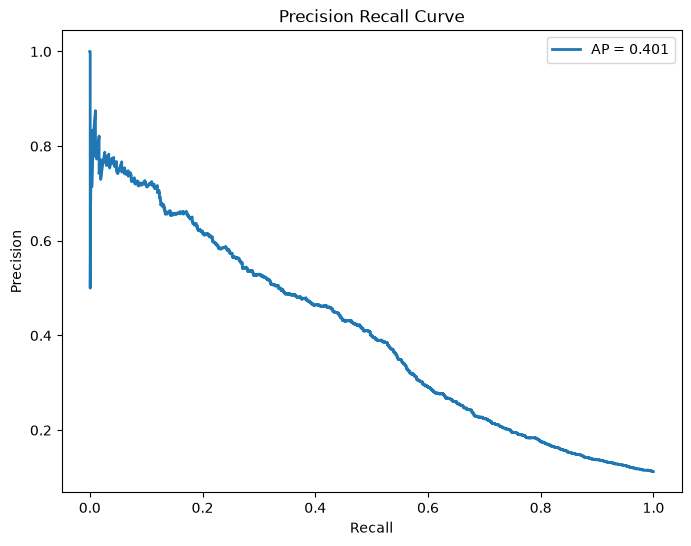

In [46]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()

SAVING A BETTER XGBOOST MODEL .

In [47]:
import joblib

joblib.dump(best_xgb, "xgboostt_model.joblib")

print("Model Saved Successfully!")

Model Saved Successfully!


XGBOOST SMOTE LEARNING AND TESTING

In [24]:
xgb_model.fit(X_train_smote, y_train_smote)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
predictions = xgb_model.predict(X_test)


In [26]:
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))
print(accuracy_score(y_test,predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     10965
           1       0.56      0.31      0.40      1392

    accuracy                           0.89     12357
   macro avg       0.74      0.64      0.67     12357
weighted avg       0.88      0.89      0.88     12357

[[10618   347]
 [  957   435]]
0.8944727684713119


In [50]:
import joblib 

# save model with joblib 
filename = 'logistic_model.joblib'
joblib.dump(logistic_model, filename)

['logistic_model.joblib']

In [53]:
# #check wieghted avg of f1, precision, recall
# from sklearn.metrics import precision_recall_fscore_support

# precision, recall, f1_score, support = precision_recall_fscore_support(y_test,predictions,average=None)

# weighted_precision_sum = 0
# weighted_recall_sum = 0
# weighted_f1_score = 0
# total_support = sum(support)

# for i in range(len(precision)):
#     weighted_precision_sum += precision[i]*support[i]
#     weighted_recall_sum += recall[i]*support[i]
#     weighted_f1_score += recall[i]*support[i]

# weighted_avg_precision = weighted_precision_sum / total_support
# weighted_avg_recall = weighted_recall_sum / total_support
# weighted_avg_f1 = weighted_f1_score / total_support

# print(f"Weighted Average Precision: {weighted_avg_precision:.2f}")
# print(f"Weighted Average recall: {weighted_avg_recall:.2f}")
# print(f"Weighted Average F1: {weighted_avg_f1:.2f}")
    

Weighted Average Precision: 0.86
Weighted Average recall: 0.86
Weighted Average F1: 0.86


# Decision tree

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
#Post prunning technique
tree_model = DecisionTreeClassifier()

In [31]:
tree_model.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [32]:
dt_predictions = tree_model.predict(X_test_scaled)

In [33]:
print(classification_report(y_test,dt_predictions))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11037
           1       0.93      1.00      0.96     10892

    accuracy                           0.96     21929
   macro avg       0.97      0.96      0.96     21929
weighted avg       0.97      0.96      0.96     21929



In [34]:
print(confusion_matrix(y_test,dt_predictions))

[[10259   778]
 [   19 10873]]


In [35]:
from sklearn import tree

[Text(0.5, 0.9, 'X[1] <= -0.384\ngini = 0.5\nsamples = 51167\nvalue = [25511, 25656]'),
 Text(0.25, 0.7, 'X[9] <= -0.558\ngini = 0.382\nsamples = 24215\nvalue = [17983, 6232]'),
 Text(0.125, 0.5, 'X[1] <= -0.733\ngini = 0.367\nsamples = 5996\nvalue = [1452, 4544]'),
 Text(0.0625, 0.3, 'X[1] <= -0.859\ngini = 0.497\nsamples = 1279\nvalue = [689, 590]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'X[3] <= -2.801\ngini = 0.271\nsamples = 4717\nvalue = [763, 3954]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'X[7] <= -1.203\ngini = 0.168\nsamples = 18219\nvalue = [16531, 1688]'),
 Text(0.3125, 0.3, 'X[1] <= -0.815\ngini = 0.499\nsamples = 2118\nvalue = [1001, 1117]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'X[45] <= 2.398\ngini = 0.068\nsamples = 16101\nvalue = [15530, 571]'),
 Text(0.40625, 0.1, '\n  (...)  \n'),
 Text(0.46875, 0.1

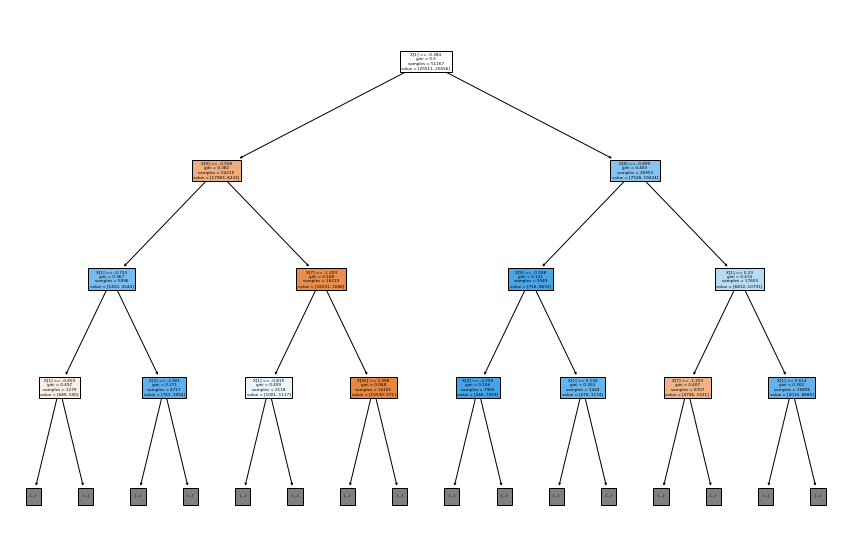

In [41]:
plt.figure(figsize=(15,10))
tree.plot_tree(tree_model,filled=True,max_depth=3)

In [36]:
path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [37]:
ccp_alphas

array([0.00000000e+00, 9.73267864e-06, 9.76858020e-06, ...,
       3.43486936e-02, 7.68986378e-02, 1.07566632e-01])

In [38]:
clfs = []
for ccp_alpha in ccp_alphas:
    tree_model = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    tree_model.fit(X_train, y_train)
    clfs.append(tree_model)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.10756663151242479


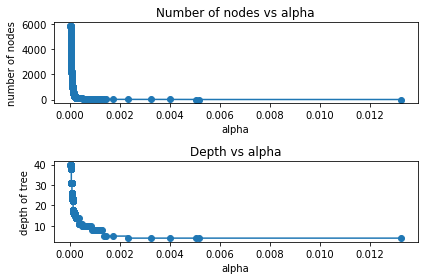

In [42]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [tree_model.tree_.node_count for tree_model in clfs]
depth = [tree_model.tree_.max_depth for tree_model in clfs]
fig, ax = plt.subplots(2,1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

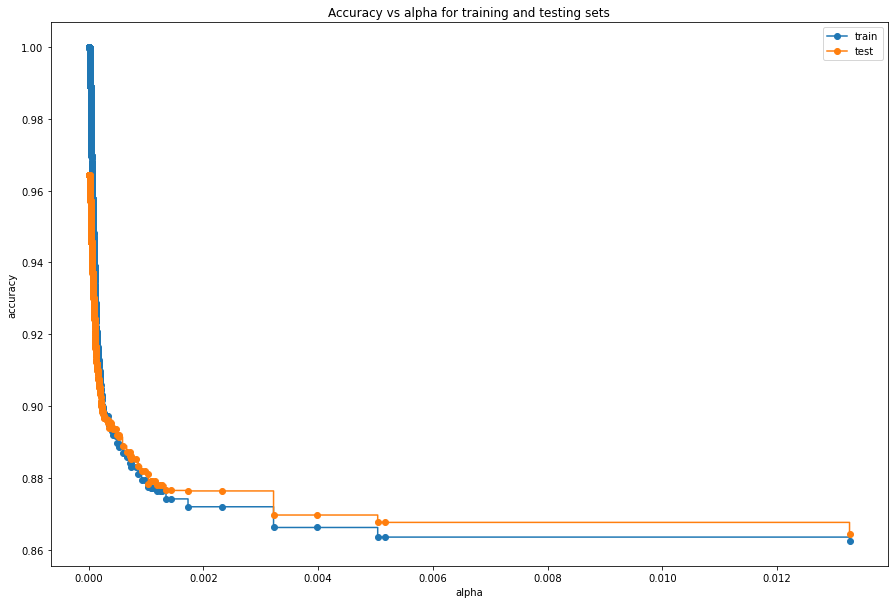

In [43]:
train_scores = [tree_model.score(X_train, y_train) for tree_model in clfs]
test_scores = [tree_model.score(X_test, y_test) for tree_model in clfs]

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [50]:
tree_model = DecisionTreeClassifier(random_state=0, ccp_alpha=0.002)
tree_model.fit(X_train_scaled,y_train)

DecisionTreeClassifier(ccp_alpha=0.002, random_state=0)

In [51]:
dt_predictions = tree_model.predict(X_test_scaled)

In [52]:
print(classification_report(y_test,dt_predictions))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87     11037
           1       0.84      0.93      0.88     10892

    accuracy                           0.88     21929
   macro avg       0.88      0.88      0.88     21929
weighted avg       0.88      0.88      0.88     21929



In [53]:
print(confusion_matrix(y_test,dt_predictions))

[[ 9115  1922]
 [  789 10103]]


In [69]:
import numpy as np

In [75]:
#Preprunning
parameters = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'splitter':['best', 'random'],
    'max_depth':list(range(10, 51)),
    'max_features':['auto', 'sqrt', 'log2'],
    'ccp_alpha': np.linspace(0.001, 0.002, 100)
}

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [77]:
tree_model = DecisionTreeClassifier()
random_search = RandomizedSearchCV(tree_model, parameters, n_iter=100, cv=5, scoring='accuracy', random_state=101)

In [78]:
random_search.fit(X_train_scaled, y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
155 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
155 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\HP\anaconda3\lib\site-packages\sklearn\tree\_classes.py", line 937, in fit
    super().fit(
  File "C:\Users\HP\anaconda3\lib\site-packages\sklearn\tree\_classes.py", line 352, in fit
    criterion = CRITERIA_CLF[self.criterion](
KeyError: 'log_loss'

  warnings.warn(some_fits_failed_message, Fi

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=100,
                   param_distributions={'ccp_alpha': array([0.001     , 0.0010101 , 0.0010202 , 0.0010303 , 0.0010404 ,
       0.00105051, 0.00106061, 0.00107071, 0.00108081, 0.00109091,
       0.00110101, 0.00111111, 0.00112121, 0.00113131, 0.00114141,
       0.00115152, 0.00116162, 0.00117172, 0.00118182, 0.00119192,
       0.00120202, 0.00121212, 0.00122...
       0.00190909, 0.00191919, 0.00192929, 0.00193939, 0.00194949,
       0.0019596 , 0.0019697 , 0.0019798 , 0.0019899 , 0.002     ]),
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      

In [79]:
random_search.best_params_

{'splitter': 'best',
 'max_features': 'sqrt',
 'max_depth': 44,
 'criterion': 'entropy',
 'ccp_alpha': 0.0014141414141414141}

In [80]:
pre_predict = random_search.predict(X_test_scaled)

In [81]:
print(classification_report(y_test,pre_predict))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83     11037
           1       0.81      0.86      0.84     10892

    accuracy                           0.83     21929
   macro avg       0.83      0.83      0.83     21929
weighted avg       0.83      0.83      0.83     21929



In [82]:
print(confusion_matrix(y_test,pre_predict))

[[8816 2221]
 [1483 9409]]


# Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
classifier = RandomForestClassifier(random_state=101)

In [55]:
classifier.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=101)

In [75]:
random_predict = classifier.predict(X_test_scaled)

In [76]:
print(classification_report(y_test,random_predict))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87     11037
           1       0.83      0.95      0.89     10892

    accuracy                           0.88     21929
   macro avg       0.89      0.88      0.88     21929
weighted avg       0.89      0.88      0.88     21929



In [77]:
print(confusion_matrix(y_test,random_predict))

[[ 8875  2162]
 [  500 10392]]


In [30]:
#preprunning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 5, 10, 15],    # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],   # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],     # Minimum number of samples required at each leaf node
    'ccp_alpha': [0.001, 0.002]        # Complexity parameter for cost-complexity pruning
}

In [33]:
randomi_search = RandomizedSearchCV(classifier,param_distributions=param_grid,cv=5,n_iter=5)

In [34]:
randomi_search.fit(X_train_scaled,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=101),
                   n_iter=5,
                   param_distributions={'ccp_alpha': [0.001, 0.002],
                                        'max_depth': [None, 5, 10, 15],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [43]:
best_rf = randomi_search.best_params_

In [40]:
random_predict = randomi_search.predict(X_test_scaled)

In [41]:
print(classification_report(y_test,random_predict))

              precision    recall  f1-score   support

           0       0.95      0.81      0.88     11037
           1       0.83      0.96      0.89     10892

    accuracy                           0.88     21929
   macro avg       0.89      0.88      0.88     21929
weighted avg       0.89      0.88      0.88     21929



In [42]:
print(confusion_matrix(y_test,random_predict))

[[ 8974  2063]
 [  490 10402]]


# Xgboost

In [23]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

In [24]:
param_dist = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'lambda': loguniform(1e-4, 1e1),  # L2 regularization (from very small to higher values)
    'alpha': loguniform(1e-4, 1e1),   # L1 regularization
}

In [25]:
xgb_model = xgb.XGBClassifier()

In [26]:
random_searchcv = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', verbose=2, random_state=101)

In [27]:
random_searchcv.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END alpha=0.03819382364892783, colsample_bytree=0.9, lambda=5.7999171503451, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END alpha=0.03819382364892783, colsample_bytree=0.9, lambda=5.7999171503451, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END alpha=0.03819382364892783, colsample_bytree=0.9, lambda=5.7999171503451, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END alpha=0.03819382364892783, colsample_bytree=0.9, lambda=5.7999171503451, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END alpha=0.03819382364892783, colsample_bytree=0.9, lambda=5.7999171503451, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END alpha=0.0034263450650962434, colsample_bytree=0.8, lambda=0.0021426083802494823, learning_rate

[CV] END alpha=0.0004901865964250323, colsample_bytree=0.9, lambda=0.00040009976899992164, learning_rate=0.001, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.6s
[CV] END alpha=0.0004901865964250323, colsample_bytree=0.9, lambda=0.00040009976899992164, learning_rate=0.001, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.7s
[CV] END alpha=0.030773110777403107, colsample_bytree=0.8, lambda=2.4430740073812043, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.9; total time=   0.7s
[CV] END alpha=0.030773110777403107, colsample_bytree=0.8, lambda=2.4430740073812043, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.9; total time=   1.1s
[CV] END alpha=0.030773110777403107, colsample_bytree=0.8, lambda=2.4430740073812043, learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.9; total time=   1.0s
[CV] END alpha=0.030773110777403107, colsample_bytree=0.8, lambda=2.4430740073812043, learning_rate=0.1, max_depth=5, n_estimators=200, 

[CV] END alpha=0.0004433045606380507, colsample_bytree=0.9, lambda=0.041838805033096414, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END alpha=0.0004433045606380507, colsample_bytree=0.9, lambda=0.041838805033096414, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END alpha=0.0004433045606380507, colsample_bytree=0.9, lambda=0.041838805033096414, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END alpha=0.0004433045606380507, colsample_bytree=0.9, lambda=0.041838805033096414, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END alpha=1.4097427612703939, colsample_bytree=0.8, lambda=5.143946514924092, learning_rate=0.001, max_depth=3, n_estimators=50, subsample=1.0; total time=   0.1s
[CV] END alpha=1.4097427612703939, colsample_bytree=0.8, lambda=5.143946514924092, learning_rate=0.001, max_depth=3, n_estimators=50, subsam

[CV] END alpha=0.00016751140430694937, colsample_bytree=0.9, lambda=0.20334124614048174, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END alpha=0.00016751140430694937, colsample_bytree=0.9, lambda=0.20334124614048174, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END alpha=0.00016751140430694937, colsample_bytree=0.9, lambda=0.20334124614048174, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END alpha=0.00016751140430694937, colsample_bytree=0.9, lambda=0.20334124614048174, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END alpha=0.00016751140430694937, colsample_bytree=0.9, lambda=0.20334124614048174, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END alpha=0.0032417899277404345, colsample_bytree=0.8, lambda=0.0017138230049099804, learning_rate=0.001, max_depth=5, n_estimator

[CV] END alpha=0.017062320233878304, colsample_bytree=1.0, lambda=0.5997943934434206, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.9; total time=   0.4s
[CV] END alpha=0.017062320233878304, colsample_bytree=1.0, lambda=0.5997943934434206, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.9; total time=   0.4s
[CV] END alpha=0.013242287704140125, colsample_bytree=1.0, lambda=0.13007652018998261, learning_rate=0.001, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.7s
[CV] END alpha=0.013242287704140125, colsample_bytree=1.0, lambda=0.13007652018998261, learning_rate=0.001, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.7s
[CV] END alpha=0.013242287704140125, colsample_bytree=1.0, lambda=0.13007652018998261, learning_rate=0.001, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.7s
[CV] END alpha=0.013242287704140125, colsample_bytree=1.0, lambda=0.13007652018998261, learning_rate=0.001, max_depth=5, n_estimators=200, 

[CV] END alpha=0.0004957217919048214, colsample_bytree=0.9, lambda=0.00011553967946508053, learning_rate=0.01, max_depth=4, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END alpha=0.0004957217919048214, colsample_bytree=0.9, lambda=0.00011553967946508053, learning_rate=0.01, max_depth=4, n_estimators=50, subsample=0.8; total time=   0.3s
[CV] END alpha=0.0004957217919048214, colsample_bytree=0.9, lambda=0.00011553967946508053, learning_rate=0.01, max_depth=4, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END alpha=0.0004957217919048214, colsample_bytree=0.9, lambda=0.00011553967946508053, learning_rate=0.01, max_depth=4, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END alpha=0.3412427610915175, colsample_bytree=0.9, lambda=0.22139084048587584, learning_rate=0.01, max_depth=4, n_estimators=50, subsample=1.0; total time=   0.2s
[CV] END alpha=0.3412427610915175, colsample_bytree=0.9, lambda=0.22139084048587584, learning_rate=0.01, max_depth=4, n_estimators=

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x000001B50A4881C0>,
             

In [31]:
X_train.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oc

In [33]:
best_model = random_searchcv.best_params_

In [34]:
best_model

{'alpha': 0.3583141390788895,
 'colsample_bytree': 0.8,
 'lambda': 0.9712256166428077,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 100,
 'subsample': 0.8}

In [60]:
# xgb_model.fit(X_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [35]:
xg_model_predict = random_searchcv.predict(X_train)

In [36]:
print(classification_report(y_train,xg_model_predict))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      3254
           1       0.89      0.95      0.92      3242

    accuracy                           0.92      6496
   macro avg       0.92      0.92      0.92      6496
weighted avg       0.92      0.92      0.92      6496



In [37]:
print(confusion_matrix(y_train,xg_model_predict))

[[2861  393]
 [ 150 3092]]


In [38]:
xgboost_predict = random_searchcv.predict(X_test)

In [39]:
print(classification_report(y_test,xgboost_predict))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1386
           1       0.86      0.93      0.89      1398

    accuracy                           0.89      2784
   macro avg       0.89      0.89      0.89      2784
weighted avg       0.89      0.89      0.89      2784



In [40]:
print(confusion_matrix(y_test,xgboost_predict))

[[1175  211]
 [ 102 1296]]


In [47]:
# Print the keys to identify the correct key corresponding to the learning rate parameter
print(random_searchcv.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_subsample', 'param_n_estimators', 'param_max_depth', 'param_learning_rate', 'param_colsample_bytree', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])


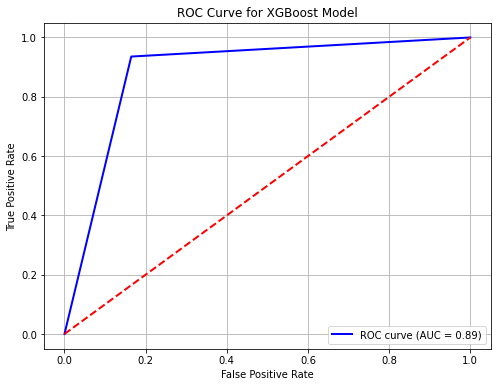

In [73]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# # Assuming you have predictions (xgboost_pred) and true labels (y_test) for XGBoost model
# fpr, tpr, _ = roc_curve(y_test, xgboost_predict)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve for XGBoost Model')
# plt.legend(loc='lower right')
# plt.grid(True)
# plt.show()


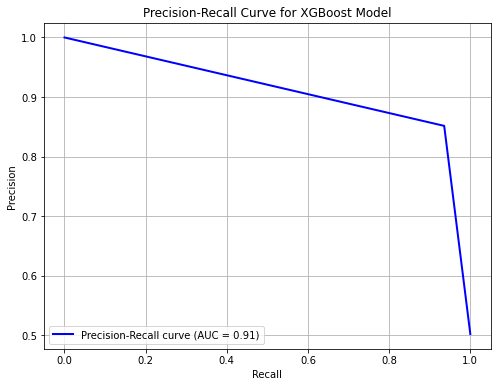

In [75]:
# from sklearn.metrics import precision_recall_curve, auc
# import matplotlib.pyplot as plt

# # Assuming you have predictions (xgboost_pred) and true labels (y_test) for XGBoost model
# precision, recall, _ = precision_recall_curve(y_test, xgboost_predict)
# pr_auc = auc(recall, precision)

# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve for XGBoost Model')
# plt.legend(loc='lower left')
# plt.grid(True)
# plt.show()

In [ ]:
# !pip install scikit-optimize

In [50]:
import joblib

In [38]:
model = joblib.load('logistic_model.joblib')

In [43]:
model.predict(X_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [41]:
import joblib 

# save model with joblib 
filename = 'xgboostt_model.joblib'
joblib.dump(random_searchcv, filename)

['xgboostt_model.joblib']

In [42]:
best_model = joblib.load('xgboostt_model.joblib')

In [43]:
final_pred = best_model.predict(X_test)

In [44]:
print(classification_report(y_test,final_pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1386
           1       0.86      0.93      0.89      1398

    accuracy                           0.89      2784
   macro avg       0.89      0.89      0.89      2784
weighted avg       0.89      0.89      0.89      2784

